In [4]:
import cv2
import pdb
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import ipywidgets as widgets
import scipy.signal, scipy.misc
import plotly.graph_objects as go

from ipywidgets import interact, IntSlider, FloatSlider
from nilearn.maskers import NiftiLabelsMasker
from nilearn.interfaces.fmriprep import load_confounds
from nilearn import plotting, datasets, image, regions
from nilearn.connectome import ConnectivityMeasure
from nilearn.decoding import Decoder
from nilearn.image import mean_img, index_img
from nilearn.datasets import MNI152_FILE_PATH, load_mni152_template
from nilearn.interfaces.fmriprep import load_confounds_strategy
from nilearn.plotting import plot_glass_brain, view_img_on_surf, plot_epi, show, plot_roi, view_img
from nibabel.testing import data_path
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import Image
from sklearn.model_selection import LeaveOneGroupOut
from skimage import data
from skimage.color import rgb2gray
from math import *
from pathlib import Path
from PIL import Image

C:\Users\deepa\AppData\Local\Temp\ipykernel_49212\2307532451.py:10: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.signal, scipy.misc


In [5]:

import glob, math, random, time, copy
from collections import OrderedDict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pytorch_msssim import ms_ssim
from extract_slices import load_nifti as load_nifti_raw, create_submission_df

In [6]:
def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_all(42)

In [7]:
def load_nifti(path: str) -> np.ndarray:
    return nib.load(path).get_fdata().astype(np.float32)

def norm01(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    mn, mx = float(x.min()), float(x.max())
    return (x - mn) / (mx - mn + 1e-8)

def psnr01(a: np.ndarray, b: np.ndarray) -> float:
    mse = float(np.mean((a - b) ** 2))
    if mse < 1e-12:
        return 50.0
    return 10.0 * math.log10(1.0 / mse)

def upsample_lf_to_hf(lf_vol: np.ndarray, target_shape) -> np.ndarray:
    x = torch.from_numpy(lf_vol).unsqueeze(0).unsqueeze(0)      # (1,1,X,Y,Z)
    x = x.permute(0, 1, 4, 3, 2)                                # (1,1,Z,Y,X)

    tx, ty, tz = target_shape                                   # target is (X,Y,Z)
    y = F.interpolate(x, size=(tz, ty, tx), mode="trilinear", align_corners=False)

    y = y.permute(0, 1, 4, 3, 2).squeeze(0).squeeze(0)          # (X,Y,Z)
    return y.cpu().numpy().astype(np.float32)

In [8]:
def build_pairs(train_low_dir="./train/low_field", train_high_dir="./train/high_field"):
    low_paths = sorted(glob.glob(os.path.join(train_low_dir, "sample_*_lowfield.nii*")))
    pairs = []
    for lp in low_paths:
        base = os.path.basename(lp)
        sample_id = base.split("_lowfield")[0]  # "sample_001"

        hp_nii = os.path.join(train_high_dir, sample_id + "_highfield.nii")
        hp_gz  = hp_nii + ".gz"
        if os.path.exists(hp_nii):
            hp = hp_nii
        elif os.path.exists(hp_gz):
            hp = hp_gz
        else:
            print("Missing high-field file for:", sample_id)
            continue

        pairs.append((lp, hp, sample_id))

    if len(pairs) == 0:
        raise RuntimeError("No training pairs found. Check your folder paths.")
    return pairs

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class ResUNet2D(nn.Module):
    def __init__(self, in_ch=5, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base*2)
        self.pool2 = nn.MaxPool2d(2)

        self.mid  = ConvBlock(base*2, base*4)

        self.up2  = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = ConvBlock(base*4, base*2)
        self.up1  = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = ConvBlock(base*2, base)

        self.out  = nn.Conv2d(base, 1, 1)
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    @staticmethod
    def _center_crop(tensor, target_h, target_w):
        _, _, h, w = tensor.shape
        y0 = max((h - target_h) // 2, 0)
        x0 = max((w - target_w) // 2, 0)
        return tensor[:, :, y0:y0+target_h, x0:x0+target_w]

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        m  = self.mid(self.pool2(e2))

        d2 = self.up2(m)
        e2c = self._center_crop(e2, d2.shape[2], d2.shape[3])
        d2  = self.dec2(torch.cat([d2, e2c], dim=1))

        d1 = self.up1(d2)
        e1c = self._center_crop(e1, d1.shape[2], d1.shape[3])
        d1  = self.dec1(torch.cat([d1, e1c], dim=1))

        r = self.out(d1)

        if r.shape[-2:] != x.shape[-2:]:
            r = F.interpolate(r, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return r

In [10]:
class MultiVolumePatches(Dataset):
    def __init__(self, pairs, k=5, patch=128, n_samples=200000, cache_size=4):
        assert k % 2 == 1
        self.pairs = pairs
        self.k = k
        self.r = k // 2
        self.patch = patch
        self.n = n_samples
        self.cache_size = cache_size
        self.cache = OrderedDict()  # sample_id -> (lf_up, hf)

    def __len__(self):
        return self.n

    def _load_pair(self, vidx):
        lp, hp, sid = self.pairs[vidx]

        if sid in self.cache:
            self.cache.move_to_end(sid)
            return self.cache[sid]

        lf = norm01(load_nifti(lp))
        hf = norm01(load_nifti(hp))
        lf_up = upsample_lf_to_hf(lf, target_shape=hf.shape)

        self.cache[sid] = (lf_up, hf)
        if len(self.cache) > self.cache_size:
            self.cache.popitem(last=False)

        return lf_up, hf

    def __getitem__(self, idx):
        vidx = random.randint(0, len(self.pairs) - 1)
        lf_up, hf = self._load_pair(vidx)

        X, Y, Z = hf.shape
        p = self.patch

        z = random.randint(self.r, Z - 1 - self.r)
        x0 = random.randint(0, X - p)
        y0 = random.randint(0, Y - p)

        chans = []
        for dz in range(-self.r, self.r + 1):
            chans.append(lf_up[x0:x0+p, y0:y0+p, z+dz])

        inp = np.stack(chans, axis=0).astype(np.float32)                 # (k,p,p)
        tgt = hf[x0:x0+p, y0:y0+p, z].astype(np.float32)[None, ...]      # (1,p,p)

        return torch.from_numpy(inp), torch.from_numpy(tgt)

In [11]:
def normalize_each(x, eps=1e-8):
    B = x.shape[0]
    xf = x.view(B, -1)
    mn = xf.min(dim=1, keepdim=True).values.view(B, 1, 1, 1)
    mx = xf.max(dim=1, keepdim=True).values.view(B, 1, 1, 1)
    return (x - mn) / (mx - mn + eps)

def loss_ms_ssim(pred, gt, w_ms=0.9, w_l1=0.1, eps=1e-8, win_size=11):
    pred_n = normalize_each(pred, eps=eps)
    gt_n   = normalize_each(gt,   eps=eps)

    ms = ms_ssim(pred_n, gt_n, data_range=1.0, size_average=True, win_size=win_size)
    l1 = (pred_n - gt_n).abs().mean()
    loss = w_ms * (1.0 - ms) + w_l1 * l1
    return loss, ms.detach(), l1.detach()


@torch.no_grad()
def ms_ssim_slice_proxy(pred2d: np.ndarray, gt2d: np.ndarray, device="cpu", eps=1e-8) -> float:
    p = (pred2d - pred2d.min()) / (pred2d.max() - pred2d.min() + eps)
    g = (gt2d   - gt2d.min())   / (gt2d.max()   - gt2d.min()   + eps)

    pt = torch.from_numpy(p[None, None]).float().to(device)  # (1,1,H,W)
    gt = torch.from_numpy(g[None, None]).float().to(device)
    val = ms_ssim(pt, gt, data_range=1.0, size_average=True, win_size=7)
    return float(val.detach().cpu().item())

In [12]:
@torch.no_grad()
def predict_one_slice(model, lf_up, z, k=5):
    device = next(model.parameters()).device
    X, Y, Z = lf_up.shape
    r = k // 2

    chans = []
    for dz in range(-r, r + 1):
        zz = min(max(z + dz, 0), Z - 1)
        chans.append(lf_up[:, :, zz])

    xfull = torch.from_numpy(np.stack(chans, axis=0))[None].float().to(device)  # (1,k,X,Y)
    rpred = model(xfull)
    center = xfull[:, k//2:k//2+1]
    pred = torch.clamp(center + rpred, 0.0, 1.0)[0, 0].cpu().numpy()
    return pred

@torch.no_grad()
def enhance_volume(model, lf_volume, k=5, batch_slices=16, target_shape=(179,221,200)):
    device = next(model.parameters()).device
    model.eval()

    lf = norm01(lf_volume)
    baseline = upsample_lf_to_hf(lf, target_shape=target_shape).astype(np.float32)

    X, Y, Z = baseline.shape
    r = k // 2

    def stack_for_z(z):
        chans = []
        for dz in range(-r, r + 1):
            zz = min(max(z + dz, 0), Z - 1)
            chans.append(baseline[:, :, zz])
        return np.stack(chans, axis=0)  # (k,X,Y)

    out = np.empty((X, Y, Z), dtype=np.float32)
    z_list = list(range(Z))

    for i in range(0, Z, batch_slices):
        zs = z_list[i:i+batch_slices]
        inp = np.stack([stack_for_z(z) for z in zs], axis=0)  # (B,k,X,Y)
        x = torch.from_numpy(inp).float().to(device)

        rpred = model(x)                                      # (B,1,X,Y)
        center = x[:, k//2:k//2+1]                            # (B,1,X,Y)
        pred = torch.clamp(center + rpred, 0.0, 1.0)          # (B,1,X,Y)

        pred_np = pred[:, 0].detach().cpu().numpy()
        for j, z in enumerate(zs):
            out[:, :, z] = pred_np[j]

    return out

In [13]:
def train_model(
    train_pairs,
    val_pairs,
    k=5,
    patch=128,
    steps=6000,
    batch_size=4,
    lr=2e-4,
    cache_size=4,
    w_ms=0.9,
    w_l1=0.1,
    ema_decay=0.999,
    eval_every=300,
    patience=5,
    val_slices_count=7,
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)
    print("Train pairs:", len(train_pairs), "Val pairs:", len(val_pairs))

    ds = MultiVolumePatches(
        train_pairs, k=k, patch=patch, n_samples=steps * batch_size, cache_size=cache_size
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

    model = ResUNet2D(in_ch=k, base=32).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # EMA copy
    ema = copy.deepcopy(model).eval()
    for p in ema.parameters():
        p.requires_grad_(False)

    def ema_update():
        with torch.no_grad():
            msd = model.state_dict()
            esd = ema.state_dict()
            for kk in esd.keys():
                esd[kk].mul_(ema_decay).add_(msd[kk], alpha=(1.0 - ema_decay))

    @torch.no_grad()
    def validate_quick():
        ema.eval()
        all_scores = []

        for (lp, hp, sid) in val_pairs:
            lf = norm01(load_nifti(lp))
            hf = norm01(load_nifti(hp))
            lf_up = upsample_lf_to_hf(lf, target_shape=hf.shape)

            Z = hf.shape[2]
            
            ts = np.linspace(0.1, 0.9, val_slices_count)
            z_list = [int(t * (Z - 1)) for t in ts]
            z_list = [min(max(z, 0), Z - 1) for z in z_list]

            for z in z_list:
                pred2d = predict_one_slice(ema, lf_up, z, k=k)
                gt2d   = hf[:, :, z]
                sc = ms_ssim_slice_proxy(pred2d, gt2d, device=device)
                all_scores.append(sc)

        return float(np.mean(all_scores)) if len(all_scores) else 0.0

    best_val = -1e9
    bad = 0
    best_ema = copy.deepcopy(ema).eval()

    model.train()
    t0 = time.time()

    for step, (x, y) in enumerate(dl):
        if step >= steps:
            break

        x = x.to(device, non_blocking=True)  # (B,k,p,p)
        y = y.to(device, non_blocking=True)  # (B,1,p,p)

        r = model(x)
        center = x[:, k//2:k//2+1]
        pred = torch.clamp(center + r, 0.0, 1.0)

        loss, ms_v, l1_v = loss_ms_ssim(pred, y, w_ms=w_ms, w_l1=w_l1, win_size=11)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        ema_update()

        if step % 200 == 0:
            elapsed = time.time() - t0
            print(f"step {step:05d} loss={loss.item():.4f} ms_ssim={ms_v.item():.4f} l1={l1_v.item():.6f} sec={elapsed:.1f}")

        if step > 0 and (step % eval_every == 0):
            val_score = validate_quick()
            print(f"  [val proxy] MS-SSIM={val_score:.5f}")

            if val_score > best_val + 1e-5:
                best_val = val_score
                bad = 0
                best_ema = copy.deepcopy(ema).eval()
            else:
                bad += 1
                if bad >= patience:
                    print("Early stopping triggered.")
                    return best_ema

    return best_ema

In [14]:
pairs = build_pairs("./train/low_field", "./train/high_field")

val_pairs = pairs[:2]
train_pairs = pairs[2:]

print("Train pairs:", len(train_pairs), "Val pairs:", len(val_pairs))

model = train_model(
    train_pairs=train_pairs,
    val_pairs=val_pairs,
    k=9,
    patch=176,
    steps=9000,
    batch_size=4,
    lr=2e-4,
    cache_size=4,
    w_ms=0.95,
    w_l1=0.05,
    eval_every=300,
    patience=10,
    val_slices_count=7,
)

lp, hp, sid = val_pairs[0]
lf = norm01(load_nifti(lp))
hf = norm01(load_nifti(hp))
lf_up = upsample_lf_to_hf(lf, target_shape=hf.shape)

zc = hf.shape[2] // 2
base = lf_up[:, :, zc]
gt   = hf[:, :, zc]
pred = predict_one_slice(model, lf_up, zc, k=9)

base_psnr = psnr01(base, gt)
pred_psnr = psnr01(pred, gt)

device = "cuda" if torch.cuda.is_available() else "cpu"
ms_slice = ms_ssim_slice_proxy(pred, gt, device=device)

print("\nValidation check on:", sid)
print("  baseline PSNR:", base_psnr)
print("  model PSNR:   ", pred_psnr)
print(f"  slice MS-SSIM: {ms_slice:.5f}")

Train pairs: 16 Val pairs: 2
Device: cuda
Train pairs: 16 Val pairs: 2
step 00000 loss=0.4108 ms_ssim=0.5731 l1=0.105806 sec=1.4
step 00200 loss=0.3252 ms_ssim=0.6634 l1=0.108342 sec=70.6
  [val proxy] MS-SSIM=0.56456
step 00400 loss=0.4338 ms_ssim=0.5493 l1=0.111546 sec=150.3
step 00600 loss=0.4749 ms_ssim=0.5056 l1=0.105644 sec=221.5
  [val proxy] MS-SSIM=0.56631
step 00800 loss=0.3879 ms_ssim=0.5964 l1=0.089735 sec=295.0
  [val proxy] MS-SSIM=0.57139
step 01000 loss=0.2801 ms_ssim=0.7095 l1=0.082310 sec=368.4
step 01200 loss=0.2675 ms_ssim=0.7231 l1=0.088777 sec=445.7
  [val proxy] MS-SSIM=0.58113
step 01400 loss=0.3092 ms_ssim=0.6798 l1=0.099863 sec=517.6
  [val proxy] MS-SSIM=0.59289
step 01600 loss=0.3433 ms_ssim=0.6436 l1=0.093859 sec=590.9
step 01800 loss=0.3561 ms_ssim=0.6306 l1=0.102918 sec=665.3
  [val proxy] MS-SSIM=0.60631
step 02000 loss=0.2245 ms_ssim=0.7678 l1=0.078185 sec=740.3
  [val proxy] MS-SSIM=0.61997
step 02200 loss=0.4167 ms_ssim=0.5672 l1=0.109702 sec=814.5
st

In [18]:
test_ids = ["sample_019", "sample_020", "sample_021", "sample_022", "sample_023"]
predictions = {}

for sample_id in test_ids:
    lf_path_nii = f"./test/low_field/{sample_id}_lowfield.nii"
    lf_path_gz  = lf_path_nii + ".gz"

    if os.path.exists(lf_path_nii):
        lf_path = lf_path_nii
    elif os.path.exists(lf_path_gz):
        lf_path = lf_path_gz
    else:
        raise FileNotFoundError(f"Missing test LF file for {sample_id}: {lf_path_nii}(.gz)")

    lf_volume = load_nifti(lf_path)  # (112,138,40)
    enhanced = enhance_volume(model, lf_volume, k=9, batch_slices=16, target_shape=(179,221,200))

    
    assert enhanced.shape == (179, 221, 200), f"Bad shape {enhanced.shape} for {sample_id}"
    assert np.isfinite(enhanced).all(), f"NaNs/Infs in output for {sample_id}"
    enhanced = np.clip(enhanced, 0.0, 1.0).astype(np.float32)

    predictions[sample_id] = enhanced

submission_df = create_submission_df(predictions)
out_name = "submission_ms_ssim17.csv"
submission_df.to_csv(out_name, index=False)
print("Created submission with", len(submission_df), "rows ->", out_name)

Created submission with 1000 rows -> submission_ms_ssim17.csv


In [19]:
import matplotlib.pyplot as plt


In [20]:
def show_side_by_side(lf_vol, hf_vol, model, z=100, k=5, title_prefix=""):
    lf_n = norm01(lf_vol)
    hf_n = norm01(hf_vol)
    baseline = upsample_lf_to_hf(lf_n, target_shape=hf_n.shape)
    pred = predict_one_slice(model, baseline, z, k=k)
    hf_slice = hf_n[:, :, z]
    base_slice = baseline[:, :, z]
    lf_z = int(round(z * (lf_n.shape[2] - 1) / (hf_n.shape[2] - 1)))
    lf_slice = lf_n[:, :, lf_z]
    diff_base = np.abs(hf_slice - base_slice)
    diff_pred = np.abs(hf_slice - pred)
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    ax = axes.ravel()
    ax[0].imshow(lf_slice.T, cmap="gray", origin="lower")
    ax[0].set_title(f"{title_prefix}LF slice (z={lf_z} in LF space)")
    ax[0].axis("off")
    ax[1].imshow(base_slice.T, cmap="gray", origin="lower")
    ax[1].set_title(f"{title_prefix}Upsampled baseline (z={z})")
    ax[1].axis("off")
    ax[2].imshow(pred.T, cmap="gray", origin="lower")
    ax[2].set_title(f"{title_prefix}Model output (z={z})")
    ax[2].axis("off")
    ax[3].imshow(hf_slice.T, cmap="gray", origin="lower")
    ax[3].set_title(f"{title_prefix}HF ground truth (z={z})")
    ax[3].axis("off")
    plt.tight_layout()
    plt.show()

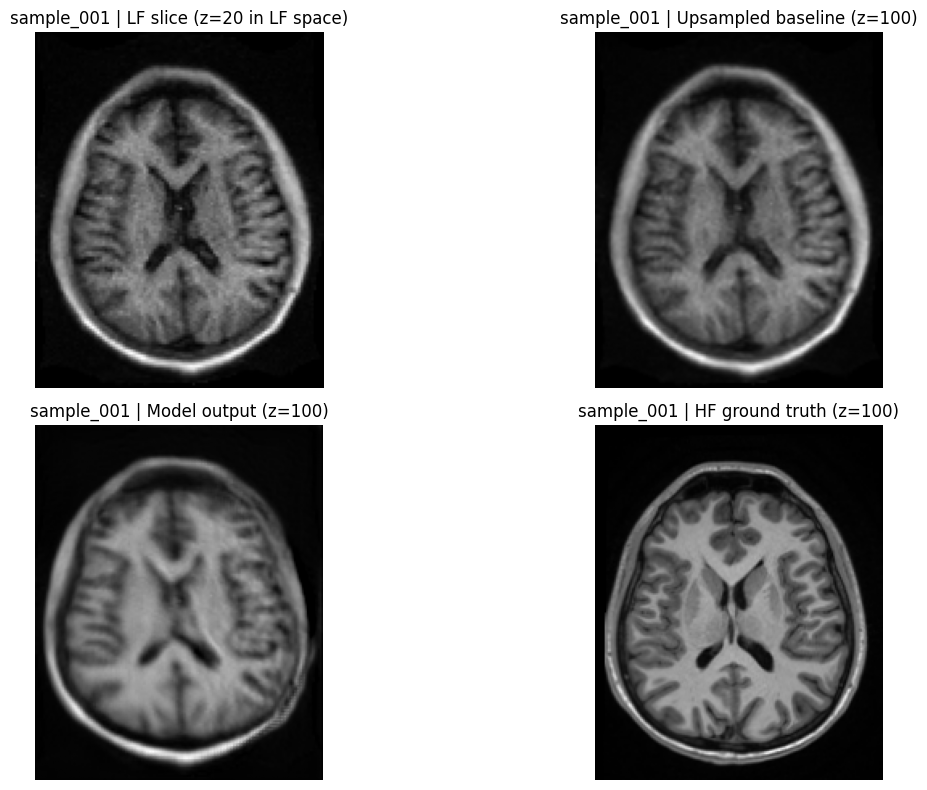

In [22]:
lp, hp, sid = val_pairs[0]
lf_vol = load_nifti(lp)
hf_vol = load_nifti(hp)

show_side_by_side(
    lf_vol=lf_vol,
    hf_vol=hf_vol,
    model=model,
    z=100,
    k=9,
    title_prefix=f"{sid} | "
)
